In [57]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.datasets import load_iris,load_wine, load_breast_cancer

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.model_selection import train_test_split

from mravens_icons import *

import tensorflow as tf

from tensorflow.keras import Sequential

from tensorflow.keras.layers import Dense

import json

# Define the file path
json_file = "config_data.json"

# Read the JSON file
with open(json_file, 'r') as file:
    data = json.load(file)

# Extract values from the data dictionary
seed = data["seed"]
f_sample = data["f_sample"]
epochs = 500
app = "iris"
lr = 0.1
b1 = 0.75
b2 = 0.999
batch_size = 16

np.random.seed(seed)

tf.random.set_seed(seed)

def one_hot(y,n):
    
    y_onehot = np.zeros((len(y),n))

    for i,j in enumerate(y):

        y_onehot[i,j]=1
        
    return y_onehot

def train_test_data(application="iris",f_sample=32,seed = 42, test_size=0.20):

    if application=="iris":

        data=load_iris()

        X,y=data['data'],data['target']  
    
    elif application=="wine":
        
        data = load_wine()

        X,y=data['data'],data['target']
        
    elif application=="breast_cancer":
        
        data=load_breast_cancer()

        X,y=data['data'],data['target']

    y_onehot = one_hot(y,np.max(y)+1)
    
    X_norm=(X-np.min(X,axis=0))/(np.max(X,axis=0)-np.min(X,axis=0))

    X_train,X_test,ytrain,ytest = train_test_split(X_norm,y,test_size=0.20,random_state=seed, stratify=y)
    
    y_train, y_test = one_hot(ytrain,np.max(y)+1), one_hot(ytest,np.max(y)+1)
    
    return X_train,X_test,y_train,y_test, ytrain,ytest

def get_GD_based_synaptic_weights(X_train,y_train,loss='categorical_crossentropy',activation='softmax',lr=0.1,
                                  b1=0.7,b2=0.999,epochs=200, batch_size=64, verbose=1,seed=42,shuffle=False):

    tf.random.set_seed(seed)

    # Define the input shape
    input_shape = (X_train.shape[1],)  # Replace input_size with the size of your input

    # Create a Sequential model
    model = Sequential()

    initializer = tf.keras.initializers.HeNormal()

    # Add the output layer directly
    model.add(Dense(units=y_train.shape[1], input_shape=input_shape, activation=activation,use_bias=False, kernel_initializer=initializer))

    opt = tf.keras.optimizers.Adam(learning_rate=lr,beta_1=b1,beta_2=b2)

    model.compile(loss=loss, optimizer=opt, metrics=['accuracy'])

    # Train the model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=verbose, validation_data=(X_test,y_test),shuffle=shuffle)

    keras_loss_train, keras_acc_train = model.evaluate(X_train, y_train, verbose=0)

    keras_loss_test, keras_acc_test= model.evaluate(X_test, y_test, verbose=0)

    keras_weights = model.get_weights()[0]
    
    return keras_loss_train, keras_acc_train, keras_loss_test, keras_acc_test, keras_weights

"""
Train_Test_Data
"""

X_train,X_test,y_train,y_test,ytrain,ytest=train_test_data(application=app,f_sample=f_sample,seed=seed, test_size=0.20)

"""
Keras Weights
"""

keras_loss_train, keras_acc_train, keras_loss_test, keras_acc_test, keras_weights = get_GD_based_synaptic_weights(X_train,y_train,activation='softmax',lr=lr,b1=b1,b2=b2,epochs=epochs, batch_size=batch_size, verbose=1,seed=seed,shuffle=False)

Epoch 1/500
8/8 [==============================] - 1s 62ms/step - loss: 1.1478 - accuracy: 0.2083 - val_loss: 0.9221 - val_accuracy: 0.4333
Epoch 2/500
8/8 [==============================] - 0s 9ms/step - loss: 0.8483 - accuracy: 0.6000 - val_loss: 0.7577 - val_accuracy: 0.6667
Epoch 3/500
8/8 [==============================] - 0s 11ms/step - loss: 0.7217 - accuracy: 0.6667 - val_loss: 0.6596 - val_accuracy: 0.6667
Epoch 4/500
8/8 [==============================] - 0s 9ms/step - loss: 0.6463 - accuracy: 0.6667 - val_loss: 0.6008 - val_accuracy: 0.6667
Epoch 5/500
8/8 [==============================] - 0s 9ms/step - loss: 0.5993 - accuracy: 0.6583 - val_loss: 0.5623 - val_accuracy: 0.6667
Epoch 6/500
8/8 [==============================] - 0s 12ms/step - loss: 0.5676 - accuracy: 0.6583 - val_loss: 0.5356 - val_accuracy: 0.6667
Epoch 7/500
8/8 [==============================] - 0s 11ms/step - loss: 0.5449 - accuracy: 0.6750 - val_loss: 0.5159 - val_accuracy: 0.6667
Epoch 8/500
8/8 [======

8/8 [==============================] - 0s 7ms/step - loss: 0.3826 - accuracy: 0.8167 - val_loss: 0.3747 - val_accuracy: 0.8333
Epoch 118/500
8/8 [==============================] - 0s 13ms/step - loss: 0.3824 - accuracy: 0.8167 - val_loss: 0.3747 - val_accuracy: 0.8333
Epoch 119/500
8/8 [==============================] - 0s 7ms/step - loss: 0.3822 - accuracy: 0.8167 - val_loss: 0.3748 - val_accuracy: 0.8333
Epoch 120/500
8/8 [==============================] - 0s 7ms/step - loss: 0.3820 - accuracy: 0.8167 - val_loss: 0.3748 - val_accuracy: 0.8333
Epoch 121/500
8/8 [==============================] - 0s 8ms/step - loss: 0.3818 - accuracy: 0.8167 - val_loss: 0.3748 - val_accuracy: 0.8333
Epoch 122/500
8/8 [==============================] - 0s 10ms/step - loss: 0.3817 - accuracy: 0.8167 - val_loss: 0.3748 - val_accuracy: 0.8333
Epoch 123/500
8/8 [==============================] - 0s 10ms/step - loss: 0.3815 - accuracy: 0.8167 - val_loss: 0.3749 - val_accuracy: 0.8333
Epoch 124/500
8/8 [=====

8/8 [==============================] - 0s 5ms/step - loss: 0.3717 - accuracy: 0.8250 - val_loss: 0.3818 - val_accuracy: 0.8667
Epoch 234/500
8/8 [==============================] - 0s 7ms/step - loss: 0.3717 - accuracy: 0.8250 - val_loss: 0.3819 - val_accuracy: 0.8667
Epoch 235/500
8/8 [==============================] - 0s 5ms/step - loss: 0.3716 - accuracy: 0.8250 - val_loss: 0.3820 - val_accuracy: 0.8667
Epoch 236/500
8/8 [==============================] - 0s 5ms/step - loss: 0.3716 - accuracy: 0.8250 - val_loss: 0.3820 - val_accuracy: 0.8667
Epoch 237/500
8/8 [==============================] - 0s 5ms/step - loss: 0.3716 - accuracy: 0.8250 - val_loss: 0.3821 - val_accuracy: 0.8667
Epoch 238/500
8/8 [==============================] - 0s 6ms/step - loss: 0.3715 - accuracy: 0.8250 - val_loss: 0.3822 - val_accuracy: 0.8667
Epoch 239/500
8/8 [==============================] - 0s 5ms/step - loss: 0.3715 - accuracy: 0.8250 - val_loss: 0.3822 - val_accuracy: 0.8667
Epoch 240/500
8/8 [========

8/8 [==============================] - 0s 5ms/step - loss: 0.3687 - accuracy: 0.8167 - val_loss: 0.3879 - val_accuracy: 0.8667
Epoch 350/500
8/8 [==============================] - 0s 5ms/step - loss: 0.3687 - accuracy: 0.8167 - val_loss: 0.3880 - val_accuracy: 0.8667
Epoch 351/500
8/8 [==============================] - 0s 5ms/step - loss: 0.3686 - accuracy: 0.8167 - val_loss: 0.3880 - val_accuracy: 0.8667
Epoch 352/500
8/8 [==============================] - 0s 5ms/step - loss: 0.3686 - accuracy: 0.8167 - val_loss: 0.3880 - val_accuracy: 0.8667
Epoch 353/500
8/8 [==============================] - 0s 5ms/step - loss: 0.3686 - accuracy: 0.8167 - val_loss: 0.3881 - val_accuracy: 0.8667
Epoch 354/500
8/8 [==============================] - 0s 5ms/step - loss: 0.3686 - accuracy: 0.8167 - val_loss: 0.3881 - val_accuracy: 0.8667
Epoch 355/500
8/8 [==============================] - 0s 5ms/step - loss: 0.3686 - accuracy: 0.8167 - val_loss: 0.3882 - val_accuracy: 0.8667
Epoch 356/500
8/8 [========

8/8 [==============================] - 0s 5ms/step - loss: 0.3672 - accuracy: 0.8250 - val_loss: 0.3915 - val_accuracy: 0.8667
Epoch 466/500
8/8 [==============================] - 0s 6ms/step - loss: 0.3672 - accuracy: 0.8250 - val_loss: 0.3915 - val_accuracy: 0.8667
Epoch 467/500
8/8 [==============================] - 0s 6ms/step - loss: 0.3672 - accuracy: 0.8250 - val_loss: 0.3916 - val_accuracy: 0.8667
Epoch 468/500
8/8 [==============================] - 0s 6ms/step - loss: 0.3672 - accuracy: 0.8250 - val_loss: 0.3916 - val_accuracy: 0.8667
Epoch 469/500
8/8 [==============================] - 0s 4ms/step - loss: 0.3672 - accuracy: 0.8250 - val_loss: 0.3916 - val_accuracy: 0.8667
Epoch 470/500
8/8 [==============================] - 0s 5ms/step - loss: 0.3672 - accuracy: 0.8250 - val_loss: 0.3916 - val_accuracy: 0.8667
Epoch 471/500
8/8 [==============================] - 0s 5ms/step - loss: 0.3671 - accuracy: 0.8250 - val_loss: 0.3916 - val_accuracy: 0.8667
Epoch 472/500
8/8 [========

In [58]:
# Sample data
data = {
"keras_loss_train":keras_loss_train, 
"keras_acc_train":keras_acc_train, 
"keras_loss_test":keras_loss_test, 
"keras_acc_test":keras_acc_test, 
"keras_weights":keras_weights.tolist()
}

# File path
file_path = f"{app}_model.json"

# Serialize data to JSON format
json_data = json.dumps(data, indent=4)

# Write JSON data to a file
with open(file_path, "w") as json_file:
    json_file.write(json_data)

print("JSON data has been saved to", file_path)

JSON data has been saved to iris_model.json


In [32]:
import json

# Read the JSON file
with open(file_path, 'r') as file:
    model_data = json.load(file)

In [33]:
model_data["keras_weights"]

[[-5.341535568237305, 4.91323184967041],
 [0.48360520601272583, -0.3608754277229309],
 [-4.419106960296631, 4.165652751922607],
 [0.6348662972450256, -0.36088311672210693],
 [-4.003285884857178, 4.0276031494140625],
 [0.7950897216796875, -0.47640812397003174],
 [5.790768146514893, -6.192703723907471],
 [9.099130630493164, -8.544677734375],
 [-2.790431499481201, 2.2741169929504395],
 [-6.705709934234619, 6.610671043395996],
 [7.020198822021484, -6.624070167541504],
 [-2.4936609268188477, 2.6727185249328613],
 [3.665112257003784, -3.2666144371032715],
 [11.590376853942871, -11.374115943908691],
 [1.9379774332046509, -1.527440071105957],
 [-1.50858473777771, 1.1853886842727661],
 [-4.573840141296387, 4.7860283851623535],
 [-1.9529228210449219, 2.565364122390747],
 [-1.6256868839263916, 1.5531665086746216],
 [-1.3095415830612183, 1.5939445495605469],
 [-0.6730878949165344, 0.8163017630577087],
 [2.2871599197387695, -2.373033285140991],
 [-1.4338407516479492, 0.9869710803031921],
 [5.366564

In [62]:
A=np.array([0.96,0.96,0.96,0.96,1,1,1,1,0.87,0.87,0.87,0.87])

B = np.array([0.82,0.87,0.93,0.95,0.78,0.89,0.94,0.97,0.83,0.93,0.97,0.97])

In [63]:
B-A

array([-0.14, -0.09, -0.03, -0.01, -0.22, -0.11, -0.06, -0.03, -0.04,
        0.06,  0.1 ,  0.1 ])

In [35]:
import pandas as pd

In [598]:
df = pd.read_csv("result_data1.csv")

meth = "D"

app = "wine"

Store_train = []

Store_test = []

Store_abs=[]

df_meth = df[df["method"]==meth]

df_meth_app = df_meth[df_meth["app"]==app]

f = 8
        
nn = df_meth_app[df_meth_app["f_sample"]==f]

nn["tt"] = nn["acctrain"] + nn["acctest"]

<ipython-input-598-bf6fb83cc4d4>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nn["tt"] = nn["acctrain"] + nn["acctest"]


In [599]:
nn[nn["tt"] == np.max(nn["tt"].values)]

,f_sample,abs_period_,epochs,abs_epoch,method,app,keras_acc_train,keras_acc_test,acctrain,acctest,absperiod,tt
48,8,4,200,50,D,wine,0.992958,1.0,0.796,0.81,[4. 4. 2.],1.606


In [368]:
1, 8, 8

(1, 8, 8)

In [133]:
np.array(Store_train) - np.array([0.96,0.96,0.96,0.96,0.99,0.99,0.99,0.99,0.83,0.83,0.83,0.83]) 

array([-0.07, -0.07, -0.07, -0.04, -0.19, -0.1 , -0.07, -0.14, -0.16,
        0.05,  0.05,  0.04])

In [134]:
np.array(Store_test) - np.array([0.96,0.96,0.96,0.96,1,1,1,1,0.87,0.87,0.87,0.87]) 

array([-0.13, -0.09, -0.03, -0.06, -0.17, -0.08, -0.08, -0.11, -0.2 ,
        0.1 ,  0.1 ,  0.06])

In [135]:
np.array(Store_train)

array([0.89, 0.89, 0.89, 0.92, 0.8 , 0.89, 0.92, 0.85, 0.67, 0.88, 0.88,
       0.87])

In [136]:
np.array(Store_test)

array([0.83, 0.87, 0.93, 0.9 , 0.83, 0.92, 0.92, 0.89, 0.67, 0.97, 0.97,
       0.93])

In [589]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.datasets import load_iris,load_wine, load_breast_cancer

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.model_selection import train_test_split

from mravens_icons import *

import tensorflow as tf

from tensorflow.keras import Sequential

from tensorflow.keras.layers import Dense

import json

def one_hot(y,n):
    
    y_onehot = np.zeros((len(y),n))

    for i,j in enumerate(y):

        y_onehot[i,j]=1
        
    return y_onehot

def train_test_data(application="iris",f_sample=32,seed = 42, test_size=0.20):

    if application=="iris":

        data=load_iris()

        X,y=data['data'],data['target']  
    
    elif application=="wine":
        
        data = load_wine()

        X,y=data['data'],data['target']
        
    elif application=="breast_cancer":
        
        data=load_breast_cancer()

        X,y=data['data'],data['target']

    y_onehot = one_hot(y,np.max(y)+1)
    
    X_norm=(X-np.min(X,axis=0))/(np.max(X,axis=0)-np.min(X,axis=0))

    X_train,X_test,ytrain,ytest = train_test_split(X_norm,y,test_size=0.20,random_state=seed, stratify=y)
    
    y_train, y_test = one_hot(ytrain,np.max(y)+1), one_hot(ytest,np.max(y)+1)
    
    return X_train,X_test,y_train,y_test, ytrain,ytest

def rate_encoded_data(X,f_sample=32):
    
    X_rate = (X*f_sample).astype('int')

    X_rate_data=np.zeros((X_rate.shape[0],X_rate.shape[1],f_sample))

    for m,sample in enumerate(X_rate):

        for n,feature in enumerate(sample):

            X_rate_data[m,n,:]=np.zeros(f_sample)

            if feature>0:

                X_rate_data[m,n,0:-1:round(f_sample/feature)]=1
                
    return X_rate_data

def get_GD_based_synaptic_weights(X_train,y_train,loss='categorical_crossentropy',activation='softmax',lr=0.1,
                                  b1=0.7,b2=0.999,epochs=200, batch_size=64, verbose=1,seed=42,shuffle=False):

    tf.random.set_seed(seed)

    # Define the input shape
    input_shape = (X_train.shape[1],)  # Replace input_size with the size of your input

    # Create a Sequential model
    model = Sequential()

    initializer = tf.keras.initializers.HeNormal()

    # Add the output layer directly
    model.add(Dense(units=y_train.shape[1], input_shape=input_shape, activation=activation,use_bias=False, kernel_initializer=initializer))

    opt = tf.keras.optimizers.Adam(learning_rate=lr,beta_1=b1,beta_2=b2)

    model.compile(loss=loss, optimizer=opt, metrics=['accuracy'])

    # Train the model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=verbose, validation_data=(X_test,y_test),shuffle=shuffle)

    keras_loss_train, keras_acc_train = model.evaluate(X_train, y_train, verbose=0)

    keras_loss_test, keras_acc_test= model.evaluate(X_test, y_test, verbose=0)

    keras_weights = model.get_weights()[0]
    
    return keras_loss_train, keras_acc_train, keras_loss_test, keras_acc_test, keras_weights

def simulate(X_rate_data,keras_weights,f_sample,st_point=[0,1,2,3],n_id =[0,1,2],
                  type_id=["output","output","output"],abs_period=[1,10,1]):

    y_pred = []
    
    spikes=[]

    for i in range(len(X_rate_data)):

        net = create_custom_network()

        net.add_stimuli(st_point,n_id,X_rate_data[i],keras_weights)

        for (i,j,k) in zip(n_id,type_id,abs_period):

            net.add_neuron(i,j)
            
            net.neuron[i].abs_period=k

        proc=MRAVENS(-5,5)

        event=process_event(f_sample,net,proc)

        event.apply_spike()

        y_pred.append(np.argmax(np.sum(event.spikes_,axis=0)))
        
        spikes.append(np.sum(event.spikes_,axis=0))
        
    return np.array(y_pred), spikes

def train_abs(X_rate_data_train,ytrain,X_rate_data_test,ytest, keras_weights,f_sample,abs_epoch,st_point=[0,1,2,3],
              n_id =[0,1,2],type_id=["output","output","output"],abs_period=np.array([5,5,5]),method="ID"):

    acc_train_list, acc_test_list, abs_period_list, spiketr_list, spikets_list = [], [], [], [], []

    for i in range(abs_epoch):

        y_pred_train, spiketr = simulate(X_rate_data_train,keras_weights,f_sample,st_point=st_point,n_id =n_id,type_id=type_id,abs_period=abs_period)

        y_pred_test, spikets = simulate(X_rate_data_test,keras_weights,f_sample,st_point=st_point,n_id =n_id,type_id=type_id,abs_period=abs_period)

        acc_train, acc_test = len(ytrain[y_pred_train==ytrain])/len(ytrain), len(ytest[y_pred_test==ytest])/len(ytest)

#         print(f"Iteration:{i+1} ::: Neuromorphic Accuracy: Train: {np.round(acc_train,3)},Test: {np.round(acc_test,3)}")

        acc_train_list.append(acc_train)

        acc_test_list.append(acc_test)

        abs_period_list.append(abs_period)
        
        spiketr_list.append(spiketr) 
        
        spikets_list.append(spikets)

#         print(f"Abs_period: {abs_period}")

        spike_dev = np.sum(one_hot(y_pred_train,y_train.shape[1])-y_train,axis=0)

#         print(f"Spike Dev: {spike_dev}")

        spike_dev_arr = np.zeros_like(spike_dev)

        idx = np.argsort(spike_dev)
        
        if method =="ID":

            spike_dev_arr[idx[0]], spike_dev_arr[idx[-1]]=  -1,1 
            
        elif method =="I":
            
            spike_dev_arr[idx[0]], spike_dev_arr[idx[-1]]=  0,1 
            
        elif method =="D":
            
            spike_dev_arr[idx[0]], spike_dev_arr[idx[-1]]=  -1,0 

        abs_period = (abs_period + spike_dev_arr).astype('int')

        abs_period[abs_period<0]=0

    acctrain, acctest, absperiod, spiketr_, spikets_ = np.array(acc_train_list), np.array(acc_test_list), np.array(abs_period_list), np.array(spiketr_list), np.array(spikets_list)

    metric = acctrain*0.50 + acctest*45 + 0.05*(1-(acctrain - acctest))  
    
    idx = np.argmax(metric)

    print(f"Best: train: {np.round(acctrain[idx],3)}, test: {np.round(acctest[idx],2)}, abs_period: {absperiod[idx]}")
    
    return acctrain, acctest, absperiod, np.round(acctrain[idx],3), np.round(acctest[idx],2), absperiod[idx], spiketr_[idx], spikets_[idx]

In [664]:
from sklearn.metrics import confusion_matrix

"""
Train_Test_Data
"""

# Define the file path
json_file = "config_data.json"

# Read the JSON file
with open(json_file, 'r') as file:
    data = json.load(file)

# Extract values from the data dictionary
seed = 42
f_sample = 64
abs_period_list = [[12,9],[3,2],[28,20]]
# abs_period_ = 3
epochs = data["epochs"]
abs_epoch = 100

app="breast_cancer"

# app_list=["iris","iris","iris"]

lr = data["lr"]
b1 = data["b1"]
b2 = data["b2"]
batch_size = data["batch_size"]

np.random.seed(seed)

tf.random.set_seed(seed)

X1, X2, X3, X4, X5, X6, X7, X8, X9 = [], [], [], [], [], [], [], [], []

Acctrain, Acctest, AbsPeriod, Spiketr_list, Spikets_list = [], [], [], [], []

conf_matrix_all=[]

# Define the file path
json_file = f"{app}_model.json"

# Read the JSON file
with open(json_file, 'r') as file:
    model_data = json.load(file)


keras_loss_train, keras_acc_train, keras_loss_test, keras_acc_test, keras_weights = model_data["keras_loss_train"], model_data["keras_acc_train"], model_data["keras_loss_test"], model_data["keras_acc_test"], np.array(model_data["keras_weights"])

"""
Rate encoded data
"""

X_rate_data_train, X_rate_data_test = rate_encoded_data(X_train,f_sample=f_sample), rate_encoded_data(X_test,f_sample=f_sample)

print(f"Keras Accuracy: Train: {np.round(keras_acc_train,3)}, Test: {np.round(keras_acc_test,3)}")

for method,abs_period  in zip(["I","D","ID"],abs_period_list): 

    X_train,X_test,y_train,y_test,ytrain,ytest=train_test_data(application=app,f_sample=f_sample,seed=seed, test_size=0.20)

    """
    Keras Weights
    """

    X_rate_data_train, X_rate_data_test = rate_encoded_data(X_train,f_sample=f_sample), rate_encoded_data(X_test,f_sample=f_sample)

    y_pred_train, spiketr = simulate(X_rate_data_train,keras_weights,f_sample,st_point=np.arange(X_train.shape[1]),
              n_id =np.arange(y_train.shape[1]),type_id=["output"]*y_train.shape[1],abs_period=abs_period)

    y_pred_test, spikets = simulate(X_rate_data_test,keras_weights,f_sample,st_point=np.arange(X_train.shape[1]),
              n_id =np.arange(y_train.shape[1]),type_id=["output"]*y_train.shape[1],abs_period=abs_period)

    y_all = np.concatenate((np.argmax(y_train,axis=1), np.argmax(y_test,axis=1)))

    y_pred_all = np.concatenate((y_pred_train,y_pred_test))

    conf_matrix_all.append(confusion_matrix(y_all, y_pred_all))

Keras Accuracy: Train: 0.96, Test: 0.956


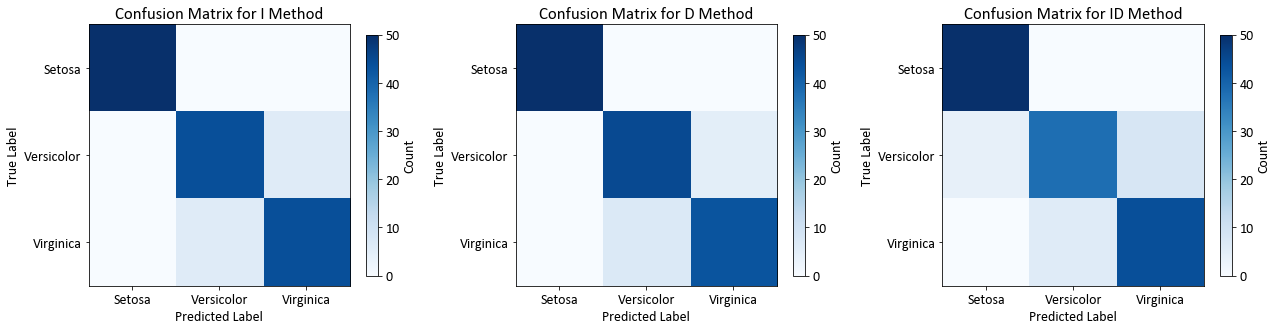

In [659]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

Method = ["I","D","ID"]

class_names = ['Setosa', 'Versicolor', 'Virginica']

for i in range(3):
    im = axes[i].imshow(conf_matrix_all[i], interpolation='nearest', cmap=plt.cm.Blues)
    axes[i].set_title(f'Confusion Matrix for {Method[i]} Method')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')
    axes[i].set_xticks(np.arange(len(class_names)))
    axes[i].set_yticks(np.arange(len(class_names)))
    axes[i].set_xticklabels(class_names)
    axes[i].set_yticklabels(class_names)
    axes[i].grid(False)
    # Add colorbar after each subplot with a smaller length
    cbar = plt.colorbar(im, ax=axes[i], shrink=0.6)
    cbar.ax.set_ylabel('Count')

plt.tight_layout()

plt.savefig("iris_64_cm1.pdf",dpi=600, bbox_inches="tight")
plt.show()

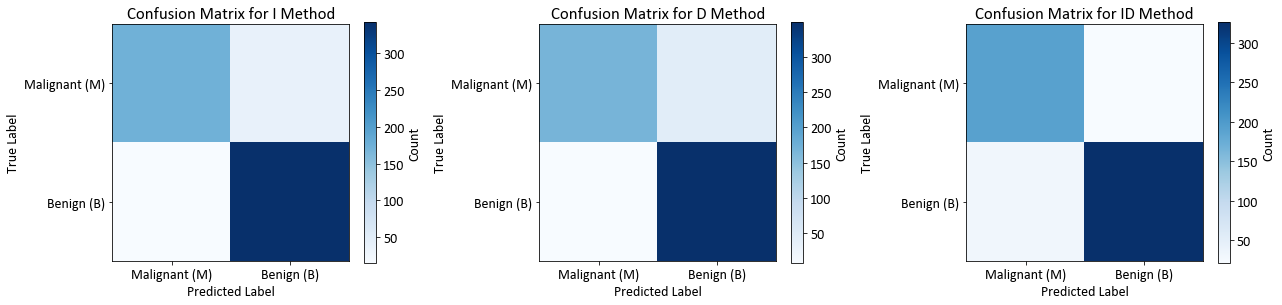

In [665]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

Method = ["I","D","ID"]

class_names = ["Malignant (M)", "Benign (B)"]

for i in range(3):
    im = axes[i].imshow(conf_matrix_all[i], interpolation='nearest', cmap=plt.cm.Blues)
    axes[i].set_title(f'Confusion Matrix for {Method[i]} Method')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')
    axes[i].set_xticks(np.arange(len(class_names)))
    axes[i].set_yticks(np.arange(len(class_names)))
    axes[i].set_xticklabels(class_names)
    axes[i].set_yticklabels(class_names)
    axes[i].grid(False)
    # Add colorbar after each subplot with a smaller length
    cbar = plt.colorbar(im, ax=axes[i], shrink=0.6)
    cbar.ax.set_ylabel('Count')

plt.tight_layout()

plt.savefig("bc_64_cm.pdf",dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
"""
Train_Test_Data
"""

# Define the file path
json_file = "config_data.json"

# Read the JSON file
with open(json_file, 'r') as file:
    data = json.load(file)

# Extract values from the data dictionary
seed = 42
f_sample = 64
abs_period_list = [[12,9], [3,2], [28,20]]
# abs_period_ = 3
epochs = data["epochs"]
abs_epoch = 100

app="iris"

# app_list=["iris","iris","iris"]

lr = data["lr"]
b1 = data["b1"]
b2 = data["b2"]
batch_size = data["batch_size"]

np.random.seed(seed)

tf.random.set_seed(seed)

X1, X2, X3, X4, X5, X6, X7, X8, X9 = [], [], [], [], [], [], [], [], []

Acctrain, Acctest, AbsPeriod, Spiketr_list, Spikets_list = [], [], [], [], []
    

for method, abs_period in zip(["I", "D", "ID"],abs_period_list):

#     method = "I"

    # for app, method, abs_period_ in zip(app_list, method_list, abs_period_list):

    X_train,X_test,y_train,y_test,ytrain,ytest=train_test_data(application=app,f_sample=f_sample,seed=seed, test_size=0.20)

    """
    Keras Weights
    """

    # Define the file path
    json_file = f"{app}_model.json"

    # Read the JSON file
    with open(json_file, 'r') as file:
        model_data = json.load(file)


    keras_loss_train, keras_acc_train, keras_loss_test, keras_acc_test, keras_weights = model_data["keras_loss_train"], model_data["keras_acc_train"], model_data["keras_loss_test"], model_data["keras_acc_test"], np.array(model_data["keras_weights"])

    """
    Rate encoded data
    """

    X_rate_data_train, X_rate_data_test = rate_encoded_data(X_train,f_sample=f_sample), rate_encoded_data(X_test,f_sample=f_sample)

    print(f"Keras Accuracy: Train: {np.round(keras_acc_train,3)}, Test: {np.round(keras_acc_test,3)}")

#     abs_period = np.ones(y_train.shape[1])*abs_period_

    y_pred_train, spiketr = simulate(X_rate_data_train,keras_weights,f_sample,st_point=np.arange(X_train.shape[1]),
              n_id =np.arange(y_train.shape[1]),type_id=["output"]*y_train.shape[1],abs_period=abs_period)

    y_pred_test, spikets = simulate(X_rate_data_test,keras_weights,f_sample,st_point=np.arange(X_train.shape[1]),
              n_id =np.arange(y_train.shape[1]),type_id=["output"]*y_train.shape[1],abs_period=abs_period)

    acc_train, acc_test = len(ytrain[y_pred_train==ytrain])/len(ytrain), len(ytest[y_pred_test==ytest])/len(ytest)
    
    print((acc_train, acc_test))

    """
    y data
    """

    yy1 = np.argmax(y_train,axis=1)

    yy2 = np.argmax(y_test,axis=1)

    yy = np.concatenate((yy1,yy2),axis=0)

    """
    Spike data
    """

    A = np.concatenate((spiketr,spikets),axis=0)


    ## y =0 for the 0, 1, 2 neuron

    data = A[yy==0][:, 0]

    X1.append(np.mean(data))

    X2.append(np.std(data))


    data = A[yy==0][:, 1]

    X1.append(np.mean(data))

    X2.append(np.std(data))


    data = A[yy==0][:, 2]

    X1.append(np.mean(data))

    X2.append(np.std(data))

    ## y =1 for the 0, 1, 2 neuron

    data = A[yy==1][:, 0]

    X1.append(np.mean(data))

    X2.append(np.std(data))


    data = A[yy==1][:, 1]

    X1.append(np.mean(data))

    X2.append(np.std(data))


    data = A[yy==1][:, 2]

    X1.append(np.mean(data))

    X2.append(np.std(data))

    ## y =2 for the 0, 1, 2 neuron

    data = A[yy==2][:, 0]

    X1.append(np.mean(data))

    X2.append(np.std(data))


    data = A[yy==2][:, 1]

    X1.append(np.mean(data))

    X2.append(np.std(data))


    data = A[yy==2][:, 2]

    X1.append(np.mean(data))

    X2.append(np.std(data))

In [607]:
with open("bc_64.json", "w") as file:
    json.dump({"X1":X1, "X2":X2}, file)

file.close()

In [643]:
with open("bc_64.json", "r") as file:
    data = json.load(file)

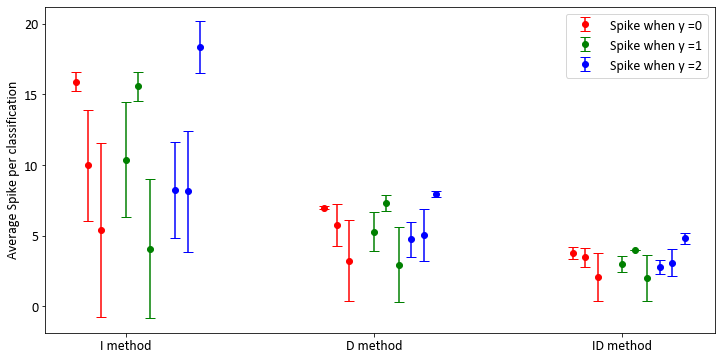

In [640]:
import numpy as np
import matplotlib.pyplot as plt
import json

# Open the JSON file and load data
with open("wine_64.json", "r") as file:
    data = json.load(file)

spacing = 20
ss = 1

# Sample data
x11 = np.arange(1, 4)  # Generate x values for the first set of points
x12 = np.arange(4, 7) + ss  # Generate x values for the first set of points
x13 = np.arange(7, 10) + 2 * ss  # Generate x values for the first set of points

x21 = np.arange(1, 4) + spacing  # Generate x values for the first set of points
x22 = np.arange(4, 7) + ss + spacing  # Generate x values for the first set of points
x23 = np.arange(7, 10) + ss + spacing  # Generate x values for the first set of points

x31 = np.arange(1, 4) + 2 * spacing  # Generate x values for the first set of points
x32 = np.arange(4, 7) + ss + 2 * spacing  # Generate x values for the first set of points
x33 = np.arange(7, 10) + ss + 2 * spacing  # Generate x values for the first set of points

# Sample data
y = data["X1"]  # Example y-values
std_dev = data["X2"]  # Example standard deviations

plt.figure(figsize=(12, 6))

plt.rc('font', size=14, family='Calibri', weight='normal')

# Create the error bar plot for the first group
plt.errorbar(x11, y[:3], yerr=std_dev[:3], fmt='o', color='red', ecolor='red', capsize=5)
plt.errorbar(x12, y[3:6], yerr=std_dev[3:6], fmt='o', color='green', ecolor='green', capsize=5)
plt.errorbar(x13, y[6:9], yerr=std_dev[6:9], fmt='o', color='blue', ecolor='blue', capsize=5)

# Create the error bar plot for the second group
plt.errorbar(x21, y[9:12], yerr=std_dev[9:12], fmt='o', color='red', ecolor='red', capsize=5)
plt.errorbar(x22, y[12:15], yerr=std_dev[12:15], fmt='o', color='green', ecolor='green', capsize=5)
plt.errorbar(x23, y[15:18], yerr=std_dev[15:18], fmt='o', color='blue', ecolor='blue', capsize=5)

# Create the error bar plot for the third group
plt.errorbar(x31, y[18:21], yerr=std_dev[18:21], fmt='o', color='red', ecolor='red', capsize=5)
plt.errorbar(x32, y[21:24], yerr=std_dev[21:24], fmt='o', color='green', ecolor='green', capsize=5)
plt.errorbar(x33, y[24:27], yerr=std_dev[24:27], fmt='o', color='blue', ecolor='blue', capsize=5)

# Add labels and title
plt.ylabel('Average Spike per classification')

# Add method labels as x-tick labels
plt.xticks([5,25,45], ['I method', 'D method', 'ID method'])

plt.legend(["Spike when y =0", "Spike when y =1", "Spike when y =2"])

plt.savefig("wine_64.pdf",dpi=600, bbox_inches = "tight")

# Show plot
plt.show()

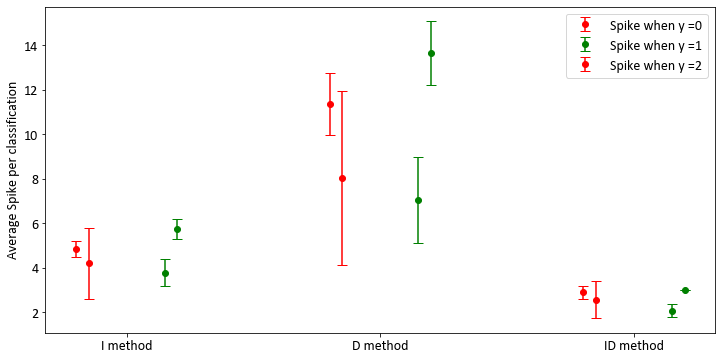

In [649]:
import numpy as np
import matplotlib.pyplot as plt
import json

# Open the JSON file and load data
with open("bc_64.json", "r") as file:
    data = json.load(file)

spacing = 20
ss = 5

# Sample data
x11 = np.arange(1, 3)  # Generate x values for the first set of points
x12 = np.arange(3, 5) + ss  # Generate x values for the first set of points

x21 = np.arange(1, 3) + spacing  # Generate x values for the first set of points
x22 = np.arange(3, 5) + ss + spacing  # Generate x values for the first set of points

x31 = np.arange(1, 3) + 2 * spacing  # Generate x values for the first set of points
x32 = np.arange(3, 5) + ss + 2 * spacing  # Generate x values for the first set of points

# Sample data
y = data["X1"]  # Example y-values
std_dev = data["X2"]  # Example standard deviations

plt.figure(figsize=(12, 6))

plt.rc('font', size=14, family='Calibri', weight='normal')

# Create the error bar plot for the first group
plt.errorbar(x11, y[:2], yerr=std_dev[:2], fmt='o', color='red', ecolor='red', capsize=5)
plt.errorbar(x12, y[2:4], yerr=std_dev[2:4], fmt='o', color='green', ecolor='green', capsize=5)

# Create the error bar plot for the second group
plt.errorbar(x21, y[4:6], yerr=std_dev[4:6], fmt='o', color='red', ecolor='red', capsize=5)
plt.errorbar(x22, y[6:8], yerr=std_dev[6:8], fmt='o', color='green', ecolor='green', capsize=5)

# Create the error bar plot for the second group
plt.errorbar(x31, y[8:10], yerr=std_dev[8:10], fmt='o', color='red', ecolor='red', capsize=5)
plt.errorbar(x32, y[10:12], yerr=std_dev[10:12], fmt='o', color='green', ecolor='green', capsize=5)

# Add labels and title
plt.ylabel('Average Spike per classification')

# Add method labels as x-tick labels
plt.xticks([5,25,45], ['I method', 'D method', 'ID method'])

plt.legend(["Spike when y =0", "Spike when y =1", "Spike when y =2"])

plt.savefig("bc_64.pdf",dpi=600, bbox_inches = "tight")

# Show plot
plt.show()

In [425]:
"""
Spike data
"""
i=1

A1 = np.array(Spiketr_list[i])

A2 = np.array(Spikets_list[i])

A = np.concatenate((A1,A2),axis=0)


## y =0 for the 0, 1, 2 neuron

data = A[yy==0][:, 0]

X4.append([np.mean(data), np.std(data)])

data = A[yy==0][:, 1]

X4.append([np.mean(data), np.std(data)])

data = A[yy==0][:, 2]

X4.append([np.mean(data), np.std(data)])

## y =1 for the 0, 1, 2 neuron

data = A[yy==1][:, 0]

X5.append([np.mean(data), np.std(data)])

data = A[yy==1][:, 1]

X5.append([np.mean(data), np.std(data)])

data = A[yy==1][:, 2]

X5.append([np.mean(data), np.std(data)])

## y =2 for the 0, 1, 2 neuron

data = A[yy==2][:, 0]

X6.append([np.mean(data), np.std(data)])

data = A[yy==2][:, 1]

X6.append([np.mean(data), np.std(data)])

data = A[yy==2][:, 2]

X6.append([np.mean(data), np.std(data)])

In [426]:
X4

[[0.56, 0.4963869458396343], [2.0, 0.0], [1.06, 0.42]]

In [427]:
X5

[[0.34, 0.47370877129308037], [2.0, 0.0], [1.68, 0.5075431016179808]]

In [429]:
X6

[[0.34, 0.47370877129308037], [2.0, 0.0], [1.68, 0.5075431016179808]]

IndexError: list index out of range

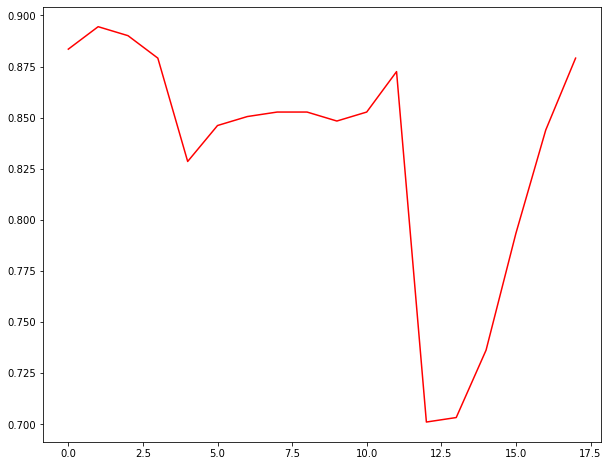

In [328]:
plt.figure(figsize=(10,8))

plt.plot(Acctrain[0][:18],"-r")

plt.plot(Acctrain[1][:25], "-g")

plt.plot(Acctrain[2][:9],"-b")

plt.ylim([0.6,0.95])

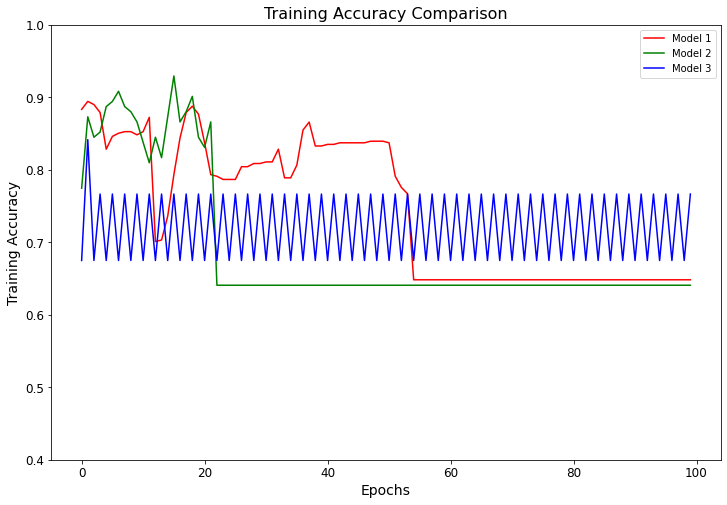

In [278]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.plot(Acctrain[0], "-r", label="Model 1")
plt.plot(Acctrain[1], "-g", label="Model 2")
plt.plot(Acctrain[2], "-b", label="Model 3")

plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Training Accuracy", fontsize=14)
plt.title("Training Accuracy Comparison", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.ylim([0.4,1])

plt.show()

In [294]:
Best = []

max_acc = 0

for i in Acctrain[0]:
    
    if i>max_acc:
        
        max_acc = i;
        
    Best.append(max_acc)
    
    
Best1 = []

max_acc = 0

for i in Acctrain[1]:
    
    if i>max_acc:
        
        max_acc = i;
        
    Best1.append(max_acc)
    
Best2 = []

max_acc = 0

for i in Acctrain[2]:
    
    if i>max_acc:
        
        max_acc = i;
        
    Best2.append(max_acc)

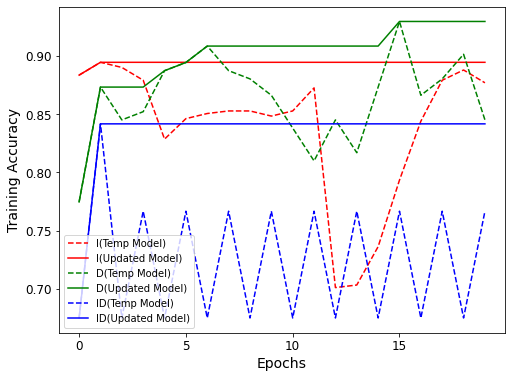

In [319]:
plt.figure(figsize=(8,6))

plt.plot(Acctrain[0][:20], "--r", label="I(Temp Model)")
plt.plot(Best[:20], "-r", label="I(Updated Model)")
plt.plot(Acctrain[1][:20], "--g", label="D(Temp Model)")
plt.plot(Best1[:20], "-g", label="D(Updated Model)")
plt.plot(Acctrain[2][:20], "--b", label="ID(Temp Model)")
plt.plot(Best2[:20], "-b", label="ID(Updated Model)")

plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Training Accuracy", fontsize=14)
plt.xticks(range(0, 20, 5), fontsize=12)
plt.yticks(fontsize=12)
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(Best[:30], label='Best')
plt.plot(Best1[:30], label='Best1')
plt.plot(Best2[:30], label='Best2')
plt.ylim([0.4, 1])
plt.xticks(range(0, 31, 5))  # Set x-axis ticks from 0 to 20 with step size 5
plt.legend()
plt.show()
